# LGCP - reproduce Ninna Vihrs 2022 - Using neural networks to estimate parameters in spatial point process models

### Loading all useful packages

In [1]:
import rdata
import numpy as np
from scipy.stats import multivariate_normal
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy.linalg import inv
from scipy.optimize import minimize
from scipy.optimize import differential_evolution, dual_annealing
from scipy import linalg
import matplotlib.pyplot as plt
import pandas as pd
import torch, numpy as np, random
torch.set_default_dtype(torch.float64)
device = torch.device('cpu')

### Set seed here

In [2]:
seed = 3010
random.seed(seed)        
np.random.seed(seed)    
torch.manual_seed(seed)  

### Loading the full dataset from .Rdata

In [4]:
LGCP_Rdata  = rdata.parser.parse_file("C:/Users/qihan/Desktop/LGCP_NV22_v4/LGCP_train10000_test5000_dataset.Rdata")
LGCP_data   = rdata.conversion.convert(LGCP_Rdata)  

### Extract main data:

In [5]:
train_L     = LGCP_data['train_L']
train_N     = LGCP_data['train_N']
train_par   = LGCP_data['train_par']
test_L      = LGCP_data['test_L']
test_N      = LGCP_data['test_N']
test_par    = LGCP_data['test_par']
test_mincon = LGCP_data['test_mincon']

### Extract other data:

In [6]:
m_L         = LGCP_data['m_L']
std_L       = LGCP_data['std_L']
m_N         = LGCP_data['m_N']
std_N       = LGCP_data['std_N']
m_par       = LGCP_data['m_par']
std_par     = LGCP_data['std_par']
seed_train  = LGCP_data['seed_train']
seed_test   = LGCP_data['seed_test']
ntrain      = LGCP_data['ntrain']
ntest       = LGCP_data['ntest']

### Dimension checks and transform data types:

In [7]:
print(train_L.shape)
print(test_L.shape)
print(train_N.shape)
print(test_N.shape)
print(train_par.shape)
print(test_par.shape)

(10000, 513, 1)
(5000, 513, 1)
(10000, 1)
(5000, 1)
(10000, 3)
(5000, 3)


In [8]:
X_L_train   = torch.as_tensor(train_L, dtype=torch.float64).permute(0, 2, 1).contiguous()  
X_L_test   = torch.as_tensor(test_L, dtype=torch.float64).permute(0, 2, 1).contiguous()
print(X_L_train.shape)
print(X_L_test.shape)

torch.Size([10000, 1, 513])
torch.Size([5000, 1, 513])


In [9]:
train_N1   = train_N.to_numpy()
test_N1    = test_N.to_numpy()
X_N_train     = torch.as_tensor(train_N1, dtype=torch.float64)
X_N_test     = torch.as_tensor(test_N1, dtype=torch.float64)                                 
print(X_N_train.shape)
print(X_N_test.shape)

torch.Size([10000, 1])
torch.Size([5000, 1])


In [10]:
train_par1 = train_par.to_numpy()
test_par1  = test_par.to_numpy()
Y_train   = torch.as_tensor(train_par1, dtype=torch.float64)                                
Y_test    = torch.as_tensor(test_par1, dtype=torch.float64)
print(Y_train.shape)
print(Y_test.shape)

torch.Size([10000, 3])
torch.Size([5000, 3])


### Transfor training, testing, response data to the device cpu here:

In [11]:
X_L_train = X_L_train.to(device)
X_L_test  = X_L_test.to(device)
X_N_train = X_N_train.to(device)
X_N_test  = X_N_test.to(device)
Y_train   = Y_train.to(device)
Y_test    = Y_test.to(device)

### Set up input dimension, sequence length and output dimension:

In [12]:
in_dim = X_L_train.shape[1]
seq_len = X_L_test.shape[2]
out_dim = Y_train.shape[1]
print(in_dim)
print(seq_len)
print(out_dim)

1
513
3


### Main model for 1d conv + 1d max pool + NN layers that followed the paper:

In [13]:
class Model(nn.Module):
    def __init__(self, in_dim, out_dim, seq_len):
        super().__init__()
        self.conv_maxpool = nn.Sequential(
            # 3 conv 1d + 2 max pool 1d
            nn.Conv1d(in_dim, 64, 7), nn.ReLU(), # in_channels, out_channels, kernel_size; https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
            nn.MaxPool1d(5), # https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool1d.html
            nn.Conv1d(64, 64, 7), nn.ReLU(),
            nn.MaxPool1d(5),
            nn.Conv1d(64, 64, 7), nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_dim, seq_len)
            flat_dim = self.conv_maxpool(dummy).view(-1).size(0)  # get the flat dim, if remove this, let flat_dim = 64*13 = 832 in this case
        
        self.dense_layer = nn.Sequential(
            nn.Linear(flat_dim + 1, 64), nn.ReLU(), # + 1 because we have a auxiliary input the number of points N. 
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, out_dim)
        )

    def forward(self, L_in, N_in):
        z = self.conv_maxpool(L_in)  # z.shape = (B, 64, 13)           
        z = z.view(z.size(0), -1)    #reshapes z into (B, 64*13) = (B, 832)
        z = torch.cat([z, N_in], dim=1)  
        return self.dense_layer(z)

### Set up model, optimazation method, loss function, batch size = 100 and epoches = 20 followed the paper:

In [14]:
model = Model(in_dim, out_dim, seq_len).to(device)
model = model.double()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_function = nn.MSELoss()
batch_size = 100 # use 100 to met the paper. the number of samples we process together in one forward/backward pass of the network.
epochs = 20 # iterations

### Set up training function to be able to make training and evaluation in one place otherwise need to write the loop twice:

In [15]:
def run_train(X_L, X_N, Y, train=True):
    num_samples = X_L.size(0)
    # train=True: training (update weights). 
    # train=False: evaluation (no update weights).
    model.train(train) 
    # model.train() is a built-in function of torch.nn.Module, input True or False to enable training or not
    # It is exactly the same as model.eval() when False.
    total = 0.0
    for i in range(0, num_samples, batch_size): 
        # range(start, stop, step), from 0 to number of samples to N mini batches by chosen step 
        L_batch = X_L[i:i+batch_size]
        N_batch = X_N[i:i+batch_size]
        Y_batch = Y[i:i+batch_size]
        
        prediction = model.forward(L_batch, N_batch)
        loss = loss_function(prediction, Y_batch)
        if train:
            opt.zero_grad() # Clears out any old gradients stored in the model parameters.
            loss.backward()
            opt.step() # Updates the model parameters using the optimizer
            
        batch_size_i = L_batch.size(0)
        Sum_of_losses_in_batch_i = loss.item()*batch_size_i
        total = total + Sum_of_losses_in_batch_i #total loss over the whole dataset from batchs.
        
    return total / num_samples

### Run the training and validation evaluation here:

In [16]:
for j in range(0, epochs):
    train = run_train(X_L_train, X_N_train, Y_train, train=True)
    validation = run_train(X_L_test, X_N_test, Y_test, train=False)
    print(f"epoch {j}  train_mse={train:.4f}  val_mse={validation:.4f}")

epoch 0  train_mse=0.6401  val_mse=0.5001
epoch 1  train_mse=0.4296  val_mse=0.3634
epoch 2  train_mse=0.3221  val_mse=0.2880
epoch 3  train_mse=0.2708  val_mse=0.2485
epoch 4  train_mse=0.2436  val_mse=0.2395
epoch 5  train_mse=0.2317  val_mse=0.2291
epoch 6  train_mse=0.2245  val_mse=0.2234
epoch 7  train_mse=0.2200  val_mse=0.2181
epoch 8  train_mse=0.2179  val_mse=0.2185
epoch 9  train_mse=0.2146  val_mse=0.2154
epoch 10  train_mse=0.2131  val_mse=0.2143
epoch 11  train_mse=0.2116  val_mse=0.2124
epoch 12  train_mse=0.2108  val_mse=0.2120
epoch 13  train_mse=0.2099  val_mse=0.2110
epoch 14  train_mse=0.2091  val_mse=0.2091
epoch 15  train_mse=0.2083  val_mse=0.2078
epoch 16  train_mse=0.2069  val_mse=0.2060
epoch 17  train_mse=0.2064  val_mse=0.2043
epoch 18  train_mse=0.2054  val_mse=0.2043
epoch 19  train_mse=0.2043  val_mse=0.2038


### Prediction for the test data, output predicted parameters:

In [17]:
model.eval()
with torch.no_grad():
    predictions = model(X_L_test, X_N_test)   # torch tensor (N_test, P)

estimate_test_par = predictions.cpu().numpy()

### Inverse the standardization for true test parameters and the predicted test parameters; Extract the mincon estimated test parameters and check the dimensions:

In [18]:
estimate_test_par = estimate_test_par*std_par + m_par
true_test_par = (test_par* std_par + m_par).to_numpy()
mincon_test_par = test_mincon.to_numpy()
print(estimate_test_par.shape)
print(true_test_par.shape)
print(mincon_test_par.shape)

(5000, 3)
(5000, 3)
(5000, 3)


### Fig. 2.

In [19]:
std_par.shape

(3,)

In [26]:
import sys
print(sys.version)

3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]


In [21]:
(estimate_test_par*std_par).shape

(5000, 3)

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


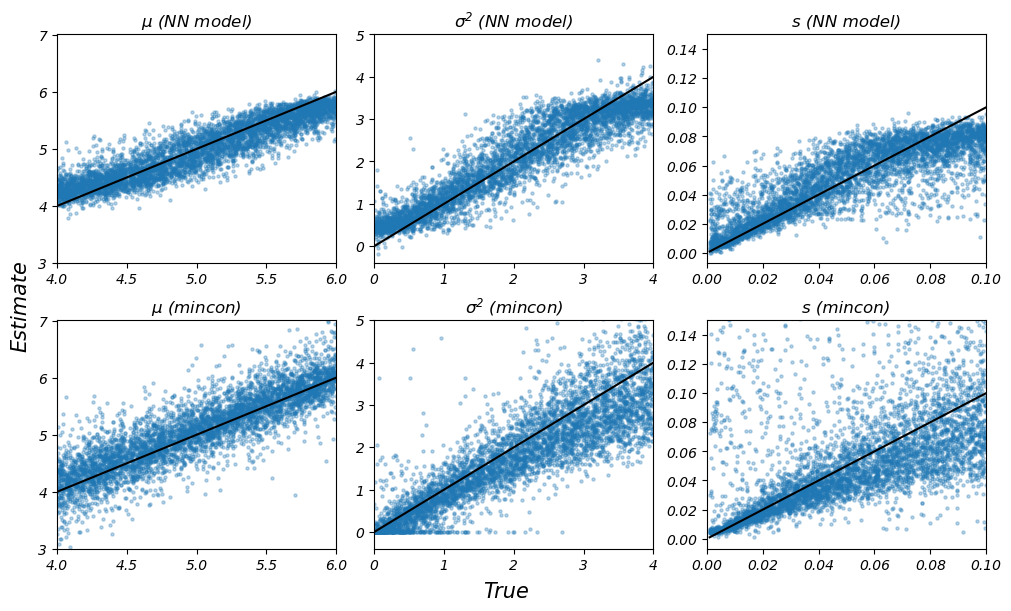

In [22]:
def plot_est_true(ax, x, y, title, xlim, ylim, diag):
    ax.scatter(x, y, s=5, alpha=0.3)               
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.plot([diag[0], diag[1]], [diag[0], diag[1]], color="black") 
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
# estimates and True
plot_est_true(axes[0,0], true_test_par[:,0], estimate_test_par[:,0], r"$\mu$ (NN model)",      xlim=(4,6),   ylim=(3,7.005),   diag=(4,6))
plot_est_true(axes[0,1], true_test_par[:,1], estimate_test_par[:,1], r"$\sigma^2$ (NN model)", xlim=(0,4),   ylim=(-0.4,5),    diag=(0,4))
plot_est_true(axes[0,2], true_test_par[:,2], estimate_test_par[:,2], r"s (NN model)",        xlim=(0,0.1), ylim=(-0.007,0.15), diag=(0.001,0.1))
# Mincon and True
plot_est_true(axes[1,0], true_test_par[:,0], mincon_test_par[:,0], r"$\mu$ (mincon)",      xlim=(4,6),   ylim=(3,7.005),     diag=(4,6))
plot_est_true(axes[1,1], true_test_par[:,1], mincon_test_par[:,1], r"$\sigma^2$ (mincon)", xlim=(0,4),   ylim=(-0.4,5),      diag=(0,4))
plot_est_true(axes[1,2], true_test_par[:,2], mincon_test_par[:,2], r"s (mincon)",        xlim=(0,0.1), ylim=(-0.007,0.15), diag=(0.001,0.1))

fig.supxlabel("True", fontsize=15)
fig.supylabel("Estimate", fontsize=15)
plt.show()

### Prediction error of the NN model:

In [23]:
# Errors (model - true)
error_mu     = estimate_test_par[:, 0] - true_test_par[:, 0]
error_var    = estimate_test_par[:, 1] - true_test_par[:, 1]
error_scale  = estimate_test_par[:, 2] - true_test_par[:, 2]
print("NN_mu_error :",error_mu.mean())
print("NN_var_error:",error_var.mean())
print("NN_s_error  :",error_scale.mean())

NN_mu_error : -0.027454333760967335
NN_var_error: 0.017362721700532303
NN_s_error  : 0.0001500096050211888


### Prediction error of the mincon model:

In [24]:
# Errors (mincon - true)
error_mu_mincon    = mincon_test_par[:, 0] - true_test_par[:, 0]
error_var_mincon   = mincon_test_par[:, 1] - true_test_par[:, 1]
error_scale_mincon = mincon_test_par[:, 2] - true_test_par[:, 2]
print("mincon_mu_error :",error_mu_mincon.mean())
print("mincon_var_error:",error_var_mincon.mean())
print("mincon_s_error  :",error_scale_mincon.mean())

mincon_mu_error : 0.0774398124449874
mincon_var_error: -0.19719526733203774
mincon_s_error  : 145.56886858815145


### For Fig. 3. question: but why use scale error vs sigma2?

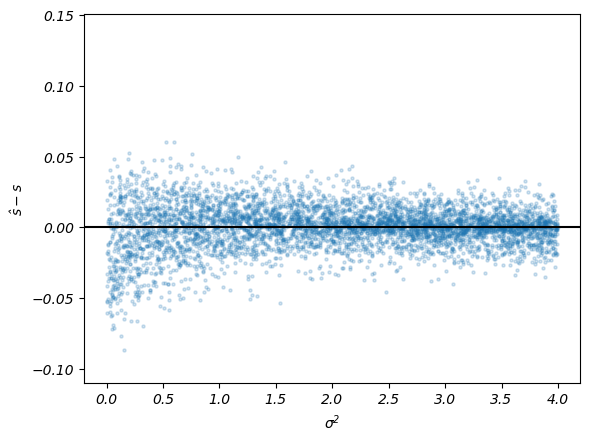

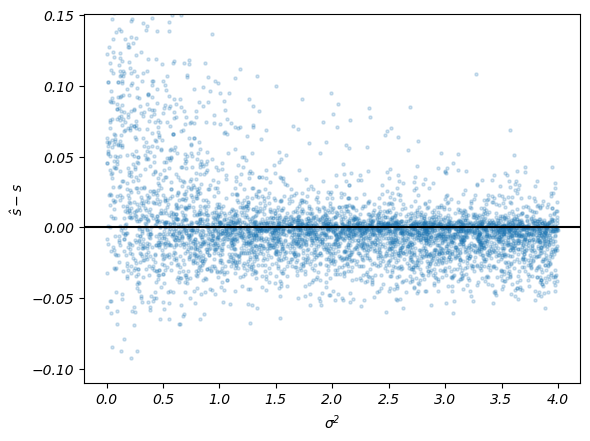

In [25]:
plt.scatter(true_test_par[:,1], error_scale, s=5, alpha=0.2) # 0 is mu, 1 is sigma2, 2 is scale
plt.axhline(0, color="black")
plt.xlabel(r"$\sigma^2$")
plt.ylabel(r"$\hat{s} - s$")
plt.ylim(-0.11, 0.151)
plt.title("") 
plt.show()

plt.scatter(true_test_par[:,1], error_scale_mincon, s=5, alpha=0.2)
plt.axhline(0, color="black")
plt.xlabel(r"$\sigma^2$")
plt.ylabel(r"$\hat{s} - s$")
plt.ylim(-0.11, 0.151)
plt.title("")
plt.show()